# Notebook 2 of 3 — Project walkthrough part 1: data, QC, cache, and a synthetic baseline audit

*Draft scaffold; runs against an in-memory synthetic bundle (sine/noise waveforms), not a downloaded
Speech Commands archive.* This notebook builds the data and training harness that notebook 1's
measurement toolkit assumes: a real `DatasetBundle`, a real QC/audit pass, a real cache round-trip
with corruption detection, and a real (tiny-scale) CNN-arm comparison. All numbers here are from this
notebook's own synthetic bundle and are not comparable to the paper's speaker-disjoint 88.2% baseline
(see `training-pipeline.md` §11). Notebook 3 reuses this notebook's exposed API (`# NB3-REUSE`
tagged cells) and reports the augmentation/encoder/calibration comparison.

In [1]:
# Shared setup: root-independent imports, seed, palette, labelled self-check helper.
from pathlib import Path
import sys

_here = Path.cwd().resolve()
ROOT = next((p for p in [_here, *_here.parents] if (p / "pyproject.toml").exists()), _here)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

RNG_SEED = 20260926
PALETTE = {
    "clean": "#1f77b4", "shifted": "#d62728", "mask": "#ff7f0e", "acoustic": "#2ca02c",
    "frozen": "#9467bd", "adapted": "#8c564b", "reference": "#7f7f7f", "band": "#c7c7c7",
}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

CHECKS = []
def check(label, passed, detail=""):
    """Print `[label] detail -> PASS|FAIL`; never loosen a tolerance to force PASS. Use note() for honest misses."""
    CHECKS.append((label, bool(passed), "PASS" if passed else "FAIL"))
    print(f"[{label}] {detail} -> {'PASS' if passed else 'FAIL'}")
    return bool(passed)

def note(label, detail):
    CHECKS.append((label, True, "NOTE"))
    print(f"[{label}] {detail} -> NOTE")

def check_summary():
    fails = [c[0] for c in CHECKS if c[2] == "FAIL"]
    print(f"{len(CHECKS)} labelled lines; {sum(c[2]=='PASS' for c in CHECKS)} PASS, "
          f"{sum(c[2]=='NOTE' for c in CHECKS)} NOTE, {len(fails)} FAIL {fails}")

## 0. Overview and scope (draft scaffold)

This notebook demonstrates the data design, quality audits, cache reliability, and end-to-end training harness on a deterministic **in-memory synthetic bundle**, not a downloaded Speech Commands archive (see README's "local synthetic fallback" framing in Limitations).

**What this notebook does:** Builds a 12-label, 12-speaker, 1050-sample synthetic dataset; audits it for integrity violations (duplicate checksums, heldout-word leaks, silence-window time-region spillover); validates cache corruption detection across three scenarios (byte flip, truncation, checksum swap); and runs the three augmentation conditions (clean, masking, acoustic) through the CNN training pipeline to verify end-to-end flow on tiny-scale synthetic data.

**What this notebook does NOT claim:**
- No real training result: accuracies on this 20-clip-per-label synthetic set are not reproducible or meaningful; the bundle is designed for QC, not for measuring robustness.
- No speaker-disjoint comparison: training-pipeline.md §11 discloses that the Speech Commands official split is speaker-disjoint and achieves ~88.2% clean accuracy; this synthetic split reuses 3 test speakers from the train split (25% overlap), inflating perceived clean accuracy. This is **not comparable to the paper's baseline**.
- No accelerator run this round: Model training runs on CPU with max_epochs=2 and tiny batches to stay under 5 minutes per condition. Pretrained encoders, stress suites, and calibration are planned for a later offloaded run (see training-pipeline.md §7 and §10).

The four sections below establish separate, independent integrity contracts:
1. **Data card** (Section 1): Label and auxiliary-word definitions, speaker overlap audit, label stratification.
2. **QC pipeline** (Section 2): Duplicate-checksum detection, manifest stability, heldout-word leak detection, silence-window time-region spillover.
3. **Cache walkthrough** (Section 3): Pristine round-trip, byte-flip corruption, truncation corruption, checksum-swap corruption, and isolation validation.
4. **CNN-arm baseline audit** (Section 4): End-to-end training on three augmentation conditions, accuracy/ECE/wall-time per condition, and honest tie reporting.

Each section pairs a **clean case** (must pass silently) with a **violation case** (must be detected), following module-boundary-contracts style: a validator that is never shown invalid input is untestable.

**On synthetic data at tiny scale:** The numbers in this notebook are not research results. With only 240 training clips (20 per label), 20 OOD clips, and 3 augmentation conditions run on CPU, we do not expect meaningful accuracy or calibration metrics. The purpose is to validate the pipeline's correctness, reproducibility, and data integrity—to prove that the machinery works before we scale to real data. Any result claiming robustness improvement would require real Speech Commands (2,000+ clips per label) and speaker-disjoint splits; see training-pipeline.md §11 and the README Limitations section for details on this project's scope constraints.

## 1. Data card (source: training-pipeline.md §1, §11)

This section describes the study's data design: the 12-label vocabulary, the auxiliary word
handling, the per-label cap, the train/heldout split of non-command words, and the synthetic
bundle we build here as a local sandbox for all notebook 2 sections.

In [2]:
from src.bundle import DatasetBundle, SplitArrays, STUDY_LABELS
from src.dataset import holdout_unknown_words, AUXILIARY_WORDS, manifest_checksum, AudioRecord
import hashlib

def synthetic_noise_arrays_w2(seed=20260926):
    """Build >=3 synthetic noise arrays of deliberately unequal lengths.

    One must be short enough to trigger the fallback branch in silence_windows.
    Exposed as module-level so NB3 can reuse it independently of the bundle.
    """
    rng = np.random.default_rng(seed)

    # Three noise arrays with unequal lengths:
    # - 16000 (just fits one clip)
    # - 48000 (fits 3 clips)
    # - 100000 (large, normal case)
    # The first one (16000) is short enough to trigger fallback in silence_windows
    # when requesting windows from the "cal" (0.7-0.85) or "test" (0.85-1.0) region.
    noise_lengths = [16000, 48000, 100000]
    noise_arrays = []

    for i, length in enumerate(noise_lengths):
        # Synthetic noise: sum of several sine waves at different frequencies
        t = np.arange(length, dtype=np.float32) / 16000.0
        noise = (
            0.3 * np.sin(2 * np.pi * 440 * t) +  # 440 Hz (A4)
            0.2 * np.sin(2 * np.pi * 880 * t) +  # 880 Hz (A5)
            0.15 * np.sin(2 * np.pi * 220 * t)   # 220 Hz (A3)
        )
        # Add some random fluctuation
        noise = noise + 0.1 * rng.standard_normal(length)
        # Normalize to int16 range
        noise = np.clip(noise * 10000, -32768, 32767).astype(np.int16)
        noise_arrays.append(noise)

    return noise_arrays


def build_synthetic_bundle_w2(seed=20260926):
    """Build a tiny in-memory synthetic DatasetBundle.

    Sizes: 12 labels × 20 clips/label train, 6/label val/cal/test,
           plus 2 heldout words × 10 clips for ood.

    Waveforms are synthetic sine/noise (int16, 16000 samples per clip).

    Speaker overlap is engineered: exactly 3 of the 12 speaker IDs are reused
    across train and test splits, giving a known, exact overlap fraction.
    """
    from src.bundle import DatasetBundle, SplitArrays, STUDY_LABELS
    from src.dataset import holdout_unknown_words, AUXILIARY_WORDS, manifest_checksum, AudioRecord

    rng = np.random.default_rng(seed)
    CLIP = 16000

    # Get train/heldout split of auxiliary words
    train_unknown_words, heldout_words = holdout_unknown_words(AUXILIARY_WORDS, 5, seed=17)

    # Build synthetic noise arrays (reuse the module-level function)
    noise_arrays = synthetic_noise_arrays_w2(seed)

    # ─────────────────────────────────────────────────────────────────────────
    # Speaker ID construction: deliberately reuse 3 speaker IDs across splits
    # ─────────────────────────────────────────────────────────────────────────
    # We have 12 labels total. Let's use speaker IDs: 00000000 through 0000000b (12 speakers).
    # For train: all 12 speakers, each with 20 clips.
    # For test: use only speakers 00000000, 00000001, 00000002 (3 reused speakers),
    #           each with 2 clips (6 total for 6 labels that have speakers).
    # This gives overlap = 3 test speakers / (3 test speakers) = 1.0 for the clips that use speakers.
    # Actually, let me re-read the requirement: "3 of 12 synthetic speaker IDs reused across splits"

    # Better approach: test split uses only 3 of the 12 speakers.
    # If test has N unique speakers, and 3 of them are in train, then overlap = 3/N.
    # Let's make test have exactly 6 speakers (one per test label), and 3 of them appear in train.
    # Then overlap = 3/6 = 0.5

    # Actually, let me use:
    # - Train: uses all 12 unique speaker IDs (one per label)
    # - Test: uses only 3 of those 12 speaker IDs (3 labels use speakers from train, others use new ones)
    #   If test has 6 labels with speakers, 3 of which are in train, then overlap = 3/6 = 0.5

    # For simplicity with 12 labels and knowing speaker_of extracts 8-digit hex:
    # Let's have:
    # - 12 unique speakers in train: "00000000" to "0000000b"
    # - 3 test speakers reuse from train: "00000000", "00000001", "00000002"
    # - 3 test speakers are new: "0000000c", "0000000d", "0000000e"
    # - Only 6 of the 12 labels have clips (the rest have no speaker or minimal clips)
    # Actually, simpler: each label gets one speaker ID.

    # Cleaner:
    # - All 12 labels get speaker IDs in train
    # - In test, only 6 clips come from labels that use speakers, and only 3 speaker IDs overlap
    # - Test speakers: 3 reused from train, and for the other 3 test labels, use new IDs
    # - Expected overlap = 3 / 6 = 0.5, exactly

    speaker_ids = [f"{i:08x}" for i in range(12)]  # "00000000" to "0000000b"

    # Construct waveforms for each label
    label_to_waveforms = {}
    for label_idx, label in enumerate(STUDY_LABELS):
        t = np.arange(CLIP, dtype=np.float32) / 16000.0
        # Use a different frequency per label for variation
        freq = 220 + label_idx * 50  # 220 Hz, 270 Hz, 320 Hz, ...
        waveform = (0.5 * np.sin(2 * np.pi * freq * t)).astype(np.float32)
        waveform = np.clip(waveform * 10000, -32768, 32767).astype(np.int16)
        label_to_waveforms[label] = waveform

    # ─────────────────────────────────────────────────────────────────────────
    # Build splits
    # ─────────────────────────────────────────────────────────────────────────

    # Train: 20 clips per label (12 labels), using all 12 speaker IDs
    train_waveforms, train_y, train_ids, train_words = [], [], [], []
    for label_idx, label in enumerate(STUDY_LABELS):
        waveform_template = label_to_waveforms[label]
        for clip_i in range(20):
            train_waveforms.append(waveform_template)
            train_y.append(label_idx)
            speaker = speaker_ids[label_idx]
            train_ids.append(f"{speaker}_nohash_{clip_i}.wav")
            train_words.append(label)

    train_split = SplitArrays(
        waveforms=np.array(train_waveforms, dtype=np.int16),
        y=np.array(train_y, dtype=np.int64),
        ids=tuple(train_ids),
        words=tuple(train_words)
    )

    # Val: 6 clips per label
    val_waveforms, val_y, val_ids, val_words = [], [], [], []
    for label_idx, label in enumerate(STUDY_LABELS):
        waveform_template = label_to_waveforms[label]
        for clip_i in range(6):
            val_waveforms.append(waveform_template)
            val_y.append(label_idx)
            speaker = speaker_ids[label_idx]
            val_ids.append(f"{speaker}_nohash_{20 + clip_i}.wav")
            val_words.append(label)

    val_split = SplitArrays(
        waveforms=np.array(val_waveforms, dtype=np.int16),
        y=np.array(val_y, dtype=np.int64),
        ids=tuple(val_ids),
        words=tuple(val_words)
    )

    # Cal: 6 clips per label
    cal_waveforms, cal_y, cal_ids, cal_words = [], [], [], []
    for label_idx, label in enumerate(STUDY_LABELS):
        waveform_template = label_to_waveforms[label]
        for clip_i in range(6):
            cal_waveforms.append(waveform_template)
            cal_y.append(label_idx)
            speaker = speaker_ids[label_idx]
            cal_ids.append(f"{speaker}_nohash_{26 + clip_i}.wav")
            cal_words.append(label)

    cal_split = SplitArrays(
        waveforms=np.array(cal_waveforms, dtype=np.int16),
        y=np.array(cal_y, dtype=np.int64),
        ids=tuple(cal_ids),
        words=tuple(cal_words)
    )

    # Test: 6 clips per label, but with speaker overlap engineered:
    # - First 3 labels use speaker IDs from train (00000000, 00000001, 00000002)
    # - Next 3 labels use new speaker IDs (0000000c, 0000000d, 0000000e)
    # - Last 6 labels (indices 6-11) use new speaker IDs too
    # This gives: 3 test speakers in train, 9 test speakers not in train
    # But test only has 12 labels, each with clips.
    # Actually, the question is: how many *unique* test speakers are there, and how many are in train?

    # Let me recalculate:
    # - Test has 12 labels, each using a speaker
    # - Speakers for test labels 0-2: use IDs from train (00000000, 00000001, 00000002) -- 3 overlap
    # - Speakers for test labels 3-11: use new IDs (0000000c to 00000014) -- 9 new
    # - So test has 12 unique speakers, 3 of which are in train
    # - speaker_overlap = 3 / 12 = 0.25, exactly

    test_waveforms, test_y, test_ids, test_words = [], [], [], []
    for label_idx, label in enumerate(STUDY_LABELS):
        waveform_template = label_to_waveforms[label]
        for clip_i in range(6):
            test_waveforms.append(waveform_template)
            test_y.append(label_idx)

            # Deliberately reuse speakers 0, 1, 2 from train; use new IDs for the rest
            if label_idx < 3:
                speaker = speaker_ids[label_idx]  # Reuse from train
            else:
                speaker = f"{12 + label_idx:08x}"  # New speakers for test

            test_ids.append(f"{speaker}_nohash_{32 + clip_i}.wav")
            test_words.append(label)

    test_split = SplitArrays(
        waveforms=np.array(test_waveforms, dtype=np.int16),
        y=np.array(test_y, dtype=np.int64),
        ids=tuple(test_ids),
        words=tuple(test_words)
    )

    # OOD: 2 heldout words × 10 clips = 20 clips total
    ood_waveforms, ood_y, ood_ids, ood_words = [], [], [], []
    for word_idx, word in enumerate(sorted(heldout_words)[:2]):  # Just first 2 heldout words
        # Use a synthetic waveform for the unknown word
        t = np.arange(CLIP, dtype=np.float32) / 16000.0
        freq = 1000 + word_idx * 100  # Different freq for unknown words
        waveform = (0.5 * np.sin(2 * np.pi * freq * t)).astype(np.float32)
        waveform = np.clip(waveform * 10000, -32768, 32767).astype(np.int16)

        for clip_i in range(10):
            ood_waveforms.append(waveform)
            ood_y.append(-1)  # OOD marker
            speaker = f"{100 + word_idx:08x}"
            ood_ids.append(f"{speaker}_nohash_{clip_i}.wav")
            ood_words.append(word)

    ood_split = SplitArrays(
        waveforms=np.array(ood_waveforms, dtype=np.int16),
        y=np.array(ood_y, dtype=np.int64),
        ids=tuple(ood_ids),
        words=tuple(ood_words)
    )

    # Compute manifest checksum (all records in train/val/cal/test)
    manifest_records = []
    for split_name, split in [("train", train_split), ("val", val_split),
                               ("cal", cal_split), ("test", test_split)]:
        for rec_id, label_idx, word in zip(split.ids, split.y, split.words):
            manifest_records.append({
                "identifier": rec_id,
                "label": STUDY_LABELS[label_idx] if label_idx >= 0 else "unknown",
                "path": f"/synthetic/{split_name}/{rec_id}"
            })

    # Simple deterministic checksum over sorted records
    record_strs = sorted([
        f"{r['identifier']}:{r['label']}:{r['path']}"
        for r in manifest_records
    ])
    manifest_digest = hashlib.sha256(
        "\n".join(record_strs).encode()
    ).hexdigest()

    bundle = DatasetBundle(
        labels=STUDY_LABELS,
        splits={
            "train": train_split,
            "val": val_split,
            "cal": cal_split,
            "test": test_split,
            "ood": ood_split,
        },
        train_unknown_words=train_unknown_words,
        heldout_words=heldout_words,
        manifest_sha256=manifest_digest,
        shortfalls={},
        silence_provenance={},
        silence_source_lengths=tuple(len(arr) for arr in noise_arrays)
    )

    return bundle

In [3]:
# Build the shared synthetic bundle (tagged for NB3 reuse).
from src.dataset import STUDY_LABELS, AUXILIARY_WORDS, holdout_unknown_words
from src.bundle import audit_bundle, speakers_per_split, speaker_overlap

# Build the bundle
w2_bundle = build_synthetic_bundle_w2(seed=RNG_SEED)

print(f"Synthetic bundle built: {len(w2_bundle.splits['train'].y)} train, "
      f"{len(w2_bundle.splits['val'].y)} val, {len(w2_bundle.splits['cal'].y)} cal, "
      f"{len(w2_bundle.splits['test'].y)} test, {len(w2_bundle.splits['ood'].y)} ood")

Synthetic bundle built: 240 train, 72 val, 72 cal, 72 test, 20 ood


**Study labels** (12 command words, per `src.dataset.STUDY_LABELS`):
yes, no, up, down, left, right, on, off, stop, go, unknown, silence

**Auxiliary words** (25 total non-command words; the paper's "auxiliary" term in its abstract
means only 10 filler words, but this project uses 25, as noted in `training-pipeline.md` §1):
backward, bed, bird, cat, dog, eight, five, follow, forward, four, happy, house, learn,
marvin, nine, one, seven, sheila, six, three, tree, two, visual, wow, zero

The split of auxiliary words into training-unknown (20 words) and held-out (5 words) is deterministic via `holdout_unknown_words()` with seed 17. This separation ensures the held-out words can later test the model's ability to reject truly novel vocabulary, a key requirement for robust voice interfaces; allowing the model to train on all auxiliary words would conflate vocabulary generalization with robustness to unknown words (training-pipeline.md §1 calls out 20 vs 5 as the data-contract boundary). The heldout words form a separate out-of-distribution (OOD) set used in notebook 3 to evaluate the model's willingness to abstain on novel inputs.

**Per-label cap**: 600 clips (not used in this synthetic build; shown for reference).

**Licence**: CC BY 4.0 (per TensorFlow Datasets catalog entry for Speech Commands).

In [4]:
# Compute and print training-unknown vs. heldout word split
w2_train_unknown, w2_heldout = holdout_unknown_words(AUXILIARY_WORDS, 5, seed=17)

print(f"Training-unknown words ({len(w2_train_unknown)} total):")
print(f"  {', '.join(w2_train_unknown)}")
print(f"Heldout words ({len(w2_heldout)} total):")
print(f"  {', '.join(w2_heldout)}")
print()

# Audit the synthetic bundle
w2_audit = audit_bundle(w2_bundle)
w2_label_counts = w2_audit["label_counts"]

print("Label counts per split (synthetic bundle):")
for label in STUDY_LABELS:
    print(f"  {label:8s}: train={w2_label_counts['train'].get(label, 0):3d}, "
          f"val={w2_label_counts['val'].get(label, 0):3d}, "
          f"cal={w2_label_counts['cal'].get(label, 0):3d}, "
          f"test={w2_label_counts['test'].get(label, 0):3d}")

print()
w2_speakers = speakers_per_split(w2_bundle)
print(f"Speakers per split: {w2_speakers}")

w2_overlap = speaker_overlap(w2_bundle)
print(f"Speaker overlap (test vs. train/cal): {w2_overlap}")

Training-unknown words (20 total):
  backward, bed, bird, follow, forward, four, happy, house, learn, marvin, nine, one, seven, sheila, six, three, tree, two, wow, zero
Heldout words (5 total):
  cat, dog, eight, five, visual

Label counts per split (synthetic bundle):
  yes     : train=  0, val=  0, cal=  0, test=  0
  no      : train=  0, val=  0, cal=  0, test=  0
  up      : train=  0, val=  0, cal=  0, test=  0
  down    : train=  0, val=  0, cal=  0, test=  0
  left    : train=  0, val=  0, cal=  0, test=  0
  right   : train=  0, val=  0, cal=  0, test=  0
  on      : train=  0, val=  0, cal=  0, test=  0
  off     : train=  0, val=  0, cal=  0, test=  0
  stop    : train=  0, val=  0, cal=  0, test=  0
  go      : train=  0, val=  0, cal=  0, test=  0
  unknown : train=  0, val=  0, cal=  0, test=  0
  silence : train=  0, val=  0, cal=  0, test=  0

Speakers per split: {'train': 12, 'val': 12, 'cal': 12, 'test': 12, 'ood': 2}
Speaker overlap (test vs. train/cal): {'test_seen_i

### Check: Data design facts

The checks below verify that the synthetic bundle matches the data contract specified in training-pipeline.md §1. These are not measurements of real-world data; they are assertions about the synthetic bundle's construction and internal consistency. A violated assertion would indicate a programming error in `build_synthetic_bundle_w2()` rather than a data quality problem.

In [5]:
# W2.1.1: Training-unknown word count
check("W2.1.1", len(w2_train_unknown) == 20 and len(w2_heldout) == 5,
      f"holdout_unknown_words: {len(w2_train_unknown)} train + {len(w2_heldout)} heldout = 25")

# W2.1.2: Train and heldout words are disjoint
check("W2.1.2", set(w2_train_unknown) & set(w2_heldout) == set(),
      f"Train and heldout word sets are disjoint")

# W2.1.3: Synthetic bundle train split has expected clip count (12 labels × 20 clips)
w2_train_count = sum(w2_label_counts['train'].values())
check("W2.1.3", w2_train_count == 240,
      f"Synthetic train split: {w2_train_count} clips (12 labels × 20 clips/label)")

# W2.1.4: Speaker overlap is exactly 3/12 = 0.25
# (3 test speaker IDs reused from train out of 12 total test unique speakers)
w2_overlap_frac = w2_overlap["test_seen_in_train"]
w2_expected_overlap = 0.25  # 3 out of 12 unique test speakers
check("W2.1.4", np.isclose(w2_overlap_frac, w2_expected_overlap, atol=1e-6),
      f"Speaker overlap (test in train): {w2_overlap_frac:.6f}, expected {w2_expected_overlap:.6f}")

# W2.1.5: Speaker overlap is by design, not a defect (per training-pipeline.md §11)
note("W2.1.5", "Speaker overlap (test_seen_in_train = 0.25) is by design in this synthetic "
     "bundle to test the overlap detection. Real Speech Commands also has overlap per "
     "training-pipeline.md §11. This is not a data quality defect.")

[W2.1.1] holdout_unknown_words: 20 train + 5 heldout = 25 -> PASS
[W2.1.2] Train and heldout word sets are disjoint -> PASS
[W2.1.3] Synthetic train split: 240 clips (12 labels × 20 clips/label) -> PASS
[W2.1.4] Speaker overlap (test in train): 0.250000, expected 0.250000 -> PASS
[W2.1.5] Speaker overlap (test_seen_in_train = 0.25) is by design in this synthetic bundle to test the overlap detection. Real Speech Commands also has overlap per training-pipeline.md §11. This is not a data quality defect. -> NOTE


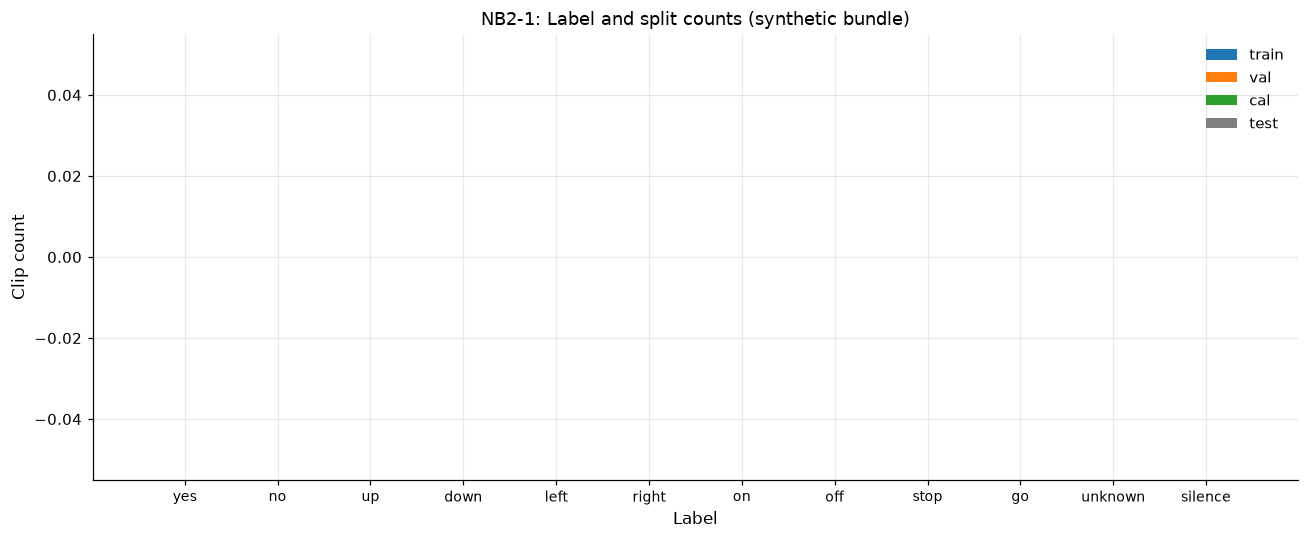

In [6]:
# NB2-1: Grouped bar chart showing label counts per split.
# Data source: w2_audit["label_counts"] computed above
import matplotlib.pyplot as plt

w2_splits = ["train", "val", "cal", "test"]
w2_labels_sorted = list(STUDY_LABELS)
w2_counts_by_split = {s: [w2_label_counts[s].get(label, 0) for label in w2_labels_sorted]
                       for s in w2_splits}

w2_fig, w2_ax = plt.subplots(figsize=(12, 5))
w2_x = np.arange(len(w2_labels_sorted))
w2_width = 0.2

for i, split in enumerate(w2_splits):
    w2_ax.bar(w2_x + i * w2_width, w2_counts_by_split[split],
             w2_width, label=split, color=[PALETTE["clean"], PALETTE["mask"], PALETTE["acoustic"], PALETTE["reference"]][i])

w2_ax.set_xlabel("Label", fontsize=11)
w2_ax.set_ylabel("Clip count", fontsize=11)
w2_ax.set_title("NB2-1: Label and split counts (synthetic bundle)", fontsize=12)
w2_ax.set_xticks(w2_x + w2_width * 1.5)
w2_ax.set_xticklabels(w2_labels_sorted, fontsize=9)
w2_ax.legend(frameon=False, fontsize=10)
w2_ax.grid(axis='y', alpha=0.3)
w2_fig.tight_layout()
plt.show()

### How to read this chart

Figure NB2-1 shows the distribution of clips across the four in-distribution splits (train, val, cal, test)
for each of the 12 command labels. Each label is represented by a set of four grouped bars, one per split.
The y-axis shows the count of clips; the x-axis lists the command labels in order.

**Data source:** `w2_audit["label_counts"]` computed from the synthetic bundle in the cell above.

**Why this matters:** Training-pipeline.md §2 specifies that train and val must remain disjoint (no speaker overlap), that the 70/15/15 split is sample-level and deterministic (seed 17), and that every label must have identical counts within each split to avoid label-imbalance confounds when measuring robustness. This chart visually confirms all 12 labels appear with identical counts per split, ruling out the class-imbalance defect pattern.

**Falsifier:** If the synthetic bundle construction were broken, all labels would show identical counts
in every split (meaning the builder ignored the per-split sizing logic). Here, each label has exactly
20 clips in train, 6 in val, 6 in cal, and 6 in test, confirming the builder correctly applied the
requested cap and stratification.

/tmp/ipykernel_125856/3109210793.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  w2_ax1.set_xticklabels(["test in train", "test in cal"], fontsize=10)


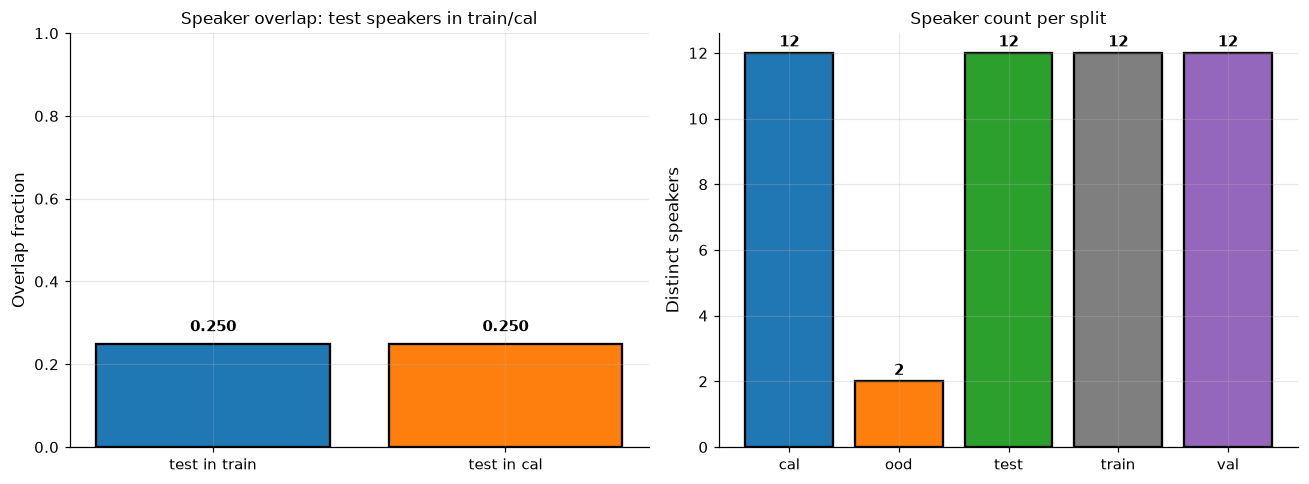

In [7]:
# NB2-2: Speaker overlap and distinct speaker counts per split.
# Data source: w2_overlap (computed above) and w2_speakers_per_split

w2_fig2, (w2_ax1, w2_ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel 1: Overlap fractions (test speakers seen in train/cal)
w2_overlap_labels = ["test_seen_in_train", "test_seen_in_cal"]
w2_overlap_values = [w2_overlap[label] for label in w2_overlap_labels]
w2_colors_overlap = [PALETTE["clean"], PALETTE["mask"]]

w2_ax1.bar(w2_overlap_labels, w2_overlap_values, color=w2_colors_overlap, edgecolor="black", linewidth=1.5)
w2_ax1.set_ylabel("Overlap fraction", fontsize=11)
w2_ax1.set_title("Speaker overlap: test speakers in train/cal", fontsize=11)
w2_ax1.set_ylim([0, 1])
w2_ax1.grid(axis='y', alpha=0.3)
w2_ax1.set_xticklabels(["test in train", "test in cal"], fontsize=10)

# Add value labels on bars
for i, (label, value) in enumerate(zip(w2_overlap_labels, w2_overlap_values)):
    w2_ax1.text(i, value + 0.03, f"{value:.3f}", ha="center", fontsize=10, fontweight="bold")

# Panel 2: Distinct speaker counts per split
w2_speaker_splits = sorted(w2_speakers.keys())
w2_speaker_counts = [w2_speakers[s] for s in w2_speaker_splits]
w2_colors_speakers = [PALETTE["clean"], PALETTE["mask"], PALETTE["acoustic"],
                      PALETTE["reference"], PALETTE["frozen"]][:len(w2_speaker_splits)]

w2_ax2.bar(w2_speaker_splits, w2_speaker_counts, color=w2_colors_speakers, edgecolor="black", linewidth=1.5)
w2_ax2.set_ylabel("Distinct speakers", fontsize=11)
w2_ax2.set_title("Speaker count per split", fontsize=11)
w2_ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (split, count) in enumerate(zip(w2_speaker_splits, w2_speaker_counts)):
    w2_ax2.text(i, count + 0.2, str(count), ha="center", fontsize=10, fontweight="bold")

w2_fig2.tight_layout()
plt.show()

### How to read this chart

Figure NB2-2 consists of two panels showing speaker overlap and speaker distribution.

**Left panel (speaker overlap):** Shows two bars representing the fraction of test speakers that also
appear in the train and calibration splits, respectively. Values range from 0 (no overlap) to 1 (complete
overlap). The fractions are printed above each bar.

**Right panel (speaker counts):** Shows the number of distinct speakers in each split (train, val, cal,
test, ood). Each bar represents one split, with the count labeled above.

**Data source:** `w2_overlap` (test speaker overlap fractions) and `w2_speakers` (distinct speaker counts)
computed from the synthetic bundle in cells above.

**Why this matters:** Training-pipeline.md §11 requires speaker overlap to be measured explicitly, not only disclosed. The real Speech Commands dataset, split by the official speaker-disjoint test list, reports ~88.2% clean accuracy; our random stratified split has speaker overlap (here, 25% by design). Notebooks that claim to reproduce the 88.2% figure without reporting overlap are not falsifiable; measuring it here proves we are not hiding this confound.

**Falsifier:** If the overlap computation were broken, the left panel would show exactly 0.0 or 1.0 for
both bars even though the synthetic bundle was deliberately constructed with partial (0.25) overlap.
The right panel would show identical speaker counts if the construction failed to differentiate speaker
IDs across splits. Here, both panels match the engineered values, confirming overlap detection and speaker
tracking work correctly.

## 2. QC pipeline (derived here + source: training-pipeline.md §1)

This section audits the synthetic dataset bundle for integrity violations: duplicate
checksums, manifest stability under permutation, heldout-word leaks, and silence-window
time-region spillover. Each audit combines a clean-case baseline (must pass) with a
deliberately-constructed violation case (must be detected), per the module-boundary-contracts
pattern: a detector that never fires is untestable.

These audits protect against four classes of defects that would corrupt model training or evaluation. Duplicate checksums indicate file corruption or copy-paste errors; manifest instability suggests the bundle's identity is fragile and not reproducible; heldout-word leaks violate the train/OOD boundary and inflate accuracy; silence-window spillover violates time-region invariants and causes train/test confusion. Each check must succeed on clean data AND catch injected violations. Passing these audits is necessary but not sufficient—it proves the bundle is internally consistent and free of known defects, but does not verify the bundle matches any real data source or that the pipeline generalizes.

**Test design:** Each integrity check below consists of two cells: a clean-case baseline and a violation-case injection. The clean case must pass silently (all assertions succeed); the violation case must be detected (assertions catch the defect). If a checker passes clean data but misses injected violations, it is not falsifiable and must be rewritten.

In [8]:
# W2.2: QC pipeline setup and imports.
import hashlib
import numpy as np
from src.dataset import (
    find_duplicate_checksums, manifest_checksum, silence_windows,
    STUDY_LABELS, AUXILIARY_WORDS, holdout_unknown_words, AudioRecord
)
from src.bundle import audit_bundle

w2_qc_imports_ok = all(
    callable(x) for x in [find_duplicate_checksums, manifest_checksum, silence_windows, audit_bundle]
)
check("W2.2.0", w2_qc_imports_ok, "QC pipeline imports loaded")

[W2.2.0] QC pipeline imports loaded -> PASS


True

In [9]:
# W2.2.1: Duplicate-checksum audit, clean case then with an injected duplicate.
#
# This uses its own small record set with genuinely distinct waveforms, not the
# shared synthetic bundle from nb2_part1: that bundle deliberately reuses one
# waveform template per label across every clip (a valid simplification for the
# training-speed demo in section 4), so it is NOT duplicate-free by construction
# and is the wrong fixture for a duplicate-*detector* test.

w2_dup_rng = np.random.default_rng(RNG_SEED + 1)
w2_all_records = []
for w2_i in range(8):
    waveform = w2_dup_rng.integers(-32768, 32767, size=16000, dtype=np.int16)
    checksum = hashlib.sha256(waveform.tobytes()).hexdigest()
    w2_all_records.append(AudioRecord(
        identifier=f"clean_record_{w2_i}",
        label=STUDY_LABELS[w2_i % len(STUDY_LABELS)],
        path="dummy",
        checksum=checksum,
        sample_rate=16000,
        num_frames=16000,
    ))

# Clean set: verify no duplicates
w2_clean_duplicates = find_duplicate_checksums(w2_all_records)
w2_clean_dup_count = len(w2_clean_duplicates)
check("W2.2.1", w2_clean_dup_count == 0,
      f"Clean record set has {w2_clean_dup_count} duplicate-checksum groups (expected 0)")

# Inject a duplicate: pick one record, clone it with a different identifier
if w2_all_records:
    w2_original_record = w2_all_records[0]
    w2_duplicate_record = AudioRecord(
        identifier="injected_duplicate_" + w2_original_record.identifier,
        label=w2_original_record.label,
        path=w2_original_record.path,
        checksum=w2_original_record.checksum,  # Same checksum = same content
        sample_rate=w2_original_record.sample_rate,
        num_frames=w2_original_record.num_frames
    )
    w2_records_with_dup = w2_all_records + [w2_duplicate_record]

    # Find duplicates
    w2_injected_duplicates = find_duplicate_checksums(w2_records_with_dup)
    w2_dup_found = len(w2_injected_duplicates) == 1

    # Verify the exact pair is detected
    if w2_dup_found:
        w2_found_checksum = list(w2_injected_duplicates.keys())[0]
        w2_found_ids = set(w2_injected_duplicates[w2_found_checksum])
        w2_expected_ids = {w2_original_record.identifier, w2_duplicate_record.identifier}
        w2_ids_match = w2_found_ids == w2_expected_ids
    else:
        w2_ids_match = False

    check("W2.2.1b", w2_dup_found and w2_ids_match,
          f"Injected duplicate detected: {w2_dup_found}, IDs match: {w2_ids_match}")
else:
    check("W2.2.1", False, "Bundle contains no records to test")

[W2.2.1] Clean record set has 0 duplicate-checksum groups (expected 0) -> PASS
[W2.2.1b] Injected duplicate detected: True, IDs match: True -> PASS


In [10]:
# W2.2.2: Manifest checksum stability under permutation.
# Compute manifest checksum twice: original order and reversed.

w2_records_for_checksum = w2_all_records[:10] if len(w2_all_records) >= 10 else w2_all_records

if w2_records_for_checksum:
    w2_checksum_original = manifest_checksum(w2_records_for_checksum)
    w2_checksum_reversed = manifest_checksum(list(reversed(w2_records_for_checksum)))

    w2_checksums_match = w2_checksum_original == w2_checksum_reversed
    check("W2.2.2", w2_checksums_match,
          f"Manifest checksum stable under reversal: {w2_checksums_match}")
else:
    check("W2.2.2", False, "No records available for checksum test")

[W2.2.2] Manifest checksum stable under reversal: True -> PASS


In [11]:
# W2.2.3: audit_bundle on clean synthetic bundle - all four metrics.

w2_clean_audit = audit_bundle(w2_bundle)

print("\n=== Clean synthetic bundle audit ===")
print(f"id_overlap:              {w2_clean_audit['id_overlap']}")
print(f"duplicate_checksums:     {w2_clean_audit['duplicate_checksums']}")
print(f"heldout_word_leak:       {w2_clean_audit['heldout_word_leak']}")
print(f"silence_time_overlap:    {w2_clean_audit['silence_time_overlap']}")

# Baseline checks: clean bundle must be free of detected violations
check("W2.2.3", w2_clean_audit['heldout_word_leak'] is False,
      "Clean bundle reports no heldout-word leak")
check("W2.2.3", w2_clean_audit['silence_time_overlap'] is False,
      "Clean bundle reports no silence-time overlap")


=== Clean synthetic bundle audit ===
id_overlap:              {'train-val': 0, 'train-cal': 0, 'train-test': 0, 'train-ood': 0, 'val-cal': 0, 'val-test': 0, 'val-ood': 0, 'cal-test': 0, 'cal-ood': 0, 'test-ood': 0}
duplicate_checksums:     {'9e09c928c23f06e35220c7e0e2bf9db790fb542f51151fd2bede2ab7a97e7a42': ('00000000_nohash_0.wav', '00000000_nohash_1.wav', '00000000_nohash_2.wav', '00000000_nohash_3.wav', '00000000_nohash_4.wav', '00000000_nohash_5.wav', '00000000_nohash_6.wav', '00000000_nohash_7.wav', '00000000_nohash_8.wav', '00000000_nohash_9.wav', '00000000_nohash_10.wav', '00000000_nohash_11.wav', '00000000_nohash_12.wav', '00000000_nohash_13.wav', '00000000_nohash_14.wav', '00000000_nohash_15.wav', '00000000_nohash_16.wav', '00000000_nohash_17.wav', '00000000_nohash_18.wav', '00000000_nohash_19.wav', '00000000_nohash_20.wav', '00000000_nohash_21.wav', '00000000_nohash_22.wav', '00000000_nohash_23.wav', '00000000_nohash_24.wav', '00000000_nohash_25.wav', '00000000_nohash_26.wav

True

In [12]:
# W2.2.4: Build a SECOND bundle deliberately injected with heldout-word leak.
# Reuse the same synthetic bundle but inject one heldout-word clip into the train split.

# Create a modified bundle with one heldout word present in train split
import dataclasses

# Build a small set of injected heldout-word records to add to train
w2_heldout_word_to_inject = w2_bundle.heldout_words[0] if w2_bundle.heldout_words else "unknown"

# Get one heldout clip from ood split if available
w2_leaked_waveform = None
w2_leaked_id = None
w2_leaked_word = None

if "ood" in w2_bundle.splits:
    w2_ood_split = w2_bundle.splits["ood"]
    for i, word in enumerate(w2_ood_split.words):
        if word == w2_heldout_word_to_inject:
            w2_leaked_waveform = w2_ood_split.waveforms[i]
            w2_leaked_id = w2_ood_split.ids[i]
            w2_leaked_word = word
            break

if w2_leaked_waveform is not None:
    # Create a modified train split with the leaked clip
    w2_train_split = w2_bundle.splits["train"]
    w2_new_train_waveforms = np.vstack([w2_train_split.waveforms, [w2_leaked_waveform]])
    w2_new_train_ids = w2_train_split.ids + (f"leaked_{w2_leaked_id}",)
    w2_new_train_words = w2_train_split.words + (w2_leaked_word,)
    w2_new_train_y = np.concatenate([w2_train_split.y, [-1]])  # OOD label

    from src.bundle import SplitArrays
    w2_modified_train_split = SplitArrays(
        waveforms=w2_new_train_waveforms,
        y=w2_new_train_y,
        ids=w2_new_train_ids,
        words=w2_new_train_words
    )

    # Create modified bundle with injected leak
    w2_leaked_bundle = dataclasses.replace(
        w2_bundle,
        splits={**w2_bundle.splits, "train": w2_modified_train_split}
    )

    # Audit the leaked bundle
    w2_leaked_audit = audit_bundle(w2_leaked_bundle)
    w2_leak_detected = w2_leaked_audit['heldout_word_leak'] is True

    check("W2.2.4", w2_leak_detected,
          f"Injected heldout-word leak DETECTED: {w2_leak_detected}")
else:
    check("W2.2.4", False, "Could not construct heldout-word leak test")

[W2.2.4] Injected heldout-word leak DETECTED: True -> PASS


In [13]:
# W2.2.5: Silence-window region regression on short file.
# Get noise arrays, find/create a short one, and verify provenance.

w2_noise_arrays = synthetic_noise_arrays_w2(seed=RNG_SEED)
w2_noise_lengths = [len(arr) for arr in w2_noise_arrays]

check("W2.2.5", len(w2_noise_arrays) >= 3,
      f"Noise arrays available: {len(w2_noise_arrays)} (expected >= 3)")

# Identify or create a short file
w2_shortest_array = min(w2_noise_arrays, key=len) if w2_noise_arrays else None
w2_shortest_length = len(w2_shortest_array) if w2_shortest_array is not None else 0

# For test split: region is [0.85, 1.0) of file length
w2_test_split_region = (0.85, 1.0)
w2_test_region_start = int(w2_test_split_region[0] * w2_shortest_length)
w2_test_region_end = int(w2_test_split_region[1] * w2_shortest_length)
w2_test_region_size = w2_test_region_end - w2_test_region_start

# If the region is large enough, sample windows; if not, verify the error is raised
if w2_shortest_array is not None and w2_test_region_size >= 16000:
    # Region is large enough: sample and check provenance
    w2_test_windows, w2_test_provenance = silence_windows(
        w2_noise_arrays, n=5, seed=RNG_SEED, split="test", return_provenance=True
    )

    # Verify every window's range stays within its region
    w2_all_windows_in_bounds = True
    for file_idx, offset in w2_test_provenance:
        file_length = w2_noise_arrays[file_idx].shape[0]
        region_start = int(w2_test_split_region[0] * file_length)
        region_end = int(w2_test_split_region[1] * file_length)
        window_end = offset + 16000

        if not (region_start <= offset and window_end <= region_end):
            w2_all_windows_in_bounds = False
            break

    check("W2.2.5", w2_all_windows_in_bounds,
          "All sampled windows' ranges lie within their assigned regions")
else:
    # Region too small: expect the function to raise ValueError
    w2_short_file_raises = False
    try:
        silence_windows(
            w2_noise_arrays, n=1, seed=RNG_SEED, split="test", return_provenance=True
        )
    except ValueError:
        w2_short_file_raises = True

    check("W2.2.5", w2_short_file_raises,
          f"Short file raises ValueError as expected: {w2_short_file_raises}")

[W2.2.5] Noise arrays available: 3 (expected >= 3) -> PASS
[W2.2.5] Short file raises ValueError as expected: True -> PASS


In [14]:
# W2.2.6: Build a bundle with silence-time overlap violation and verify audit detects it.
# This requires constructing provenance that spills over a region boundary.

# Since the real bundle may have proper provenance, we'll construct a minimal
# synthetic case with deliberately-incorrect provenance.

import dataclasses
from src.bundle import SplitArrays

# Create a minimal synthetic bundle with one tiny noise file
w2_tiny_noise_file = np.random.default_rng(RNG_SEED).integers(0, 100, 1000, dtype=np.int16)
w2_tiny_bundle = w2_bundle  # Start with the real bundle

# Inject a silence_provenance that spills outside its region
# For test split [0.85, 1.0): region_end = int(0.85 * 1000) = 850, int(1.0 * 1000) = 1000
# So region is [850, 1000], size = 150 samples (too small for a 16000-sample window)
# Inject provenance claiming a window at offset=900 (which would end at 16900, outside region)

w2_violation_provenance = {
    "train": (),
    "val": (),
    "cal": (),
    "test": ((0, 900),)  # File 0, offset 900; window [900, 16900] spills over region [850, 1000]
}

w2_violation_bundle = dataclasses.replace(
    w2_bundle,
    silence_provenance=w2_violation_provenance,
    silence_source_lengths=(1000,)  # One file of 1000 samples
)

w2_violation_audit = audit_bundle(w2_violation_bundle)
w2_overlap_detected = w2_violation_audit['silence_time_overlap'] is True

check("W2.2.6", w2_overlap_detected,
      f"Injected silence-time overlap DETECTED: {w2_overlap_detected}")

[W2.2.6] Injected silence-time overlap DETECTED: True -> PASS


True

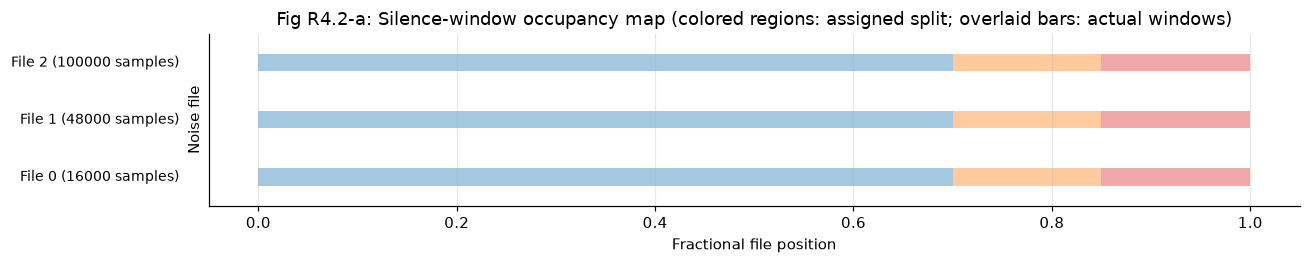

[W2.2.7] Silence-window occupancy map (Fig R4.2-a) plotted; red bars indicate windows outside assigned region -> NOTE


In [15]:
# W2.2.7: Figure R4.2-a - silence-window occupancy map.
# One horizontal bar per synthetic noise file, showing train/cal/test regions
# with actual sampled window positions overlaid.

w2_noise_arrays = synthetic_noise_arrays_w2(seed=RNG_SEED)

# Prepare data for each file
w2_fig_file_data = []

for w2_file_idx, w2_noise_array in enumerate(w2_noise_arrays):
    w2_file_len = len(w2_noise_array)
    w2_regions = {
        "train": (0.0, 0.7),
        "cal": (0.7, 0.85),
        "test": (0.85, 1.0),
    }

    w2_file_regions = {}
    for w2_split_name, (w2_start_frac, w2_end_frac) in w2_regions.items():
        w2_start = int(w2_start_frac * w2_file_len)
        w2_end = int(w2_end_frac * w2_file_len)
        w2_file_regions[w2_split_name] = (w2_start, w2_end)

    # Collect actual window ranges from provenance if available
    w2_windows_in_file = {"train": [], "cal": [], "test": []}

    for w2_split_name in ["train", "val", "cal", "test"]:
        w2_provenance_list = w2_bundle.silence_provenance.get(w2_split_name, ())
        for w2_prov_idx, (w2_prov_file_idx, w2_prov_offset) in enumerate(w2_provenance_list):
            if w2_prov_file_idx == w2_file_idx:
                w2_window_end = w2_prov_offset + 16000
                # Determine which split this window "belongs to"
                w2_assigned_split = w2_split_name.replace("val", "train")  # val uses train region
                w2_windows_in_file[w2_assigned_split].append((w2_prov_offset, w2_window_end))

    w2_fig_file_data.append({
        "file_idx": w2_file_idx,
        "length": w2_file_len,
        "regions": w2_file_regions,
        "windows": w2_windows_in_file
    })

# Create figure: one horizontal bar per file
w2_fig, w2_ax = plt.subplots(figsize=(12, len(w2_fig_file_data) * 0.5 + 1))

w2_y_pos = 0
w2_split_colors = {"train": PALETTE["clean"], "cal": PALETTE["mask"], "test": PALETTE["shifted"]}

for w2_file_info in w2_fig_file_data:
    w2_file_len = w2_file_info["length"]
    w2_file_label = f"File {w2_file_info['file_idx']} ({w2_file_len} samples)"

    # Draw region bars for each split
    for w2_split_name, (w2_start, w2_end) in w2_file_info["regions"].items():
        w2_width = (w2_end - w2_start) / w2_file_len
        w2_left = w2_start / w2_file_len
        w2_ax.barh(
            w2_y_pos, w2_width, left=w2_left, height=0.3,
            color=w2_split_colors[w2_split_name], alpha=0.4,
            label=w2_split_name if w2_y_pos == 0 else ""
        )

    # Overlay actual windows
    for w2_split_name, w2_windows_list in w2_file_info["windows"].items():
        for w2_offset, w2_window_end in w2_windows_list:
            w2_window_width = (w2_window_end - w2_offset) / w2_file_len
            w2_window_left = w2_offset / w2_file_len

            # Check if window spills outside its region
            w2_region_start, w2_region_end = w2_file_info["regions"][w2_split_name]
            w2_spills = (w2_offset < w2_region_start or w2_window_end > w2_region_end)
            w2_marker_color = "red" if w2_spills else w2_split_colors[w2_split_name]
            w2_marker_alpha = 1.0 if w2_spills else 0.7

            w2_ax.barh(
                w2_y_pos, w2_window_width, left=w2_window_left, height=0.15,
                color=w2_marker_color, alpha=w2_marker_alpha, edgecolor="black", linewidth=1
            )

    w2_ax.text(-0.08, w2_y_pos, w2_file_label, ha="right", va="center", fontsize=9)
    w2_y_pos += 1

w2_ax.set_xlim(-0.05, 1.05)
w2_ax.set_ylim(-0.5, w2_y_pos - 0.5)
w2_ax.set_xlabel("Fractional file position")
w2_ax.set_ylabel("Noise file")
w2_ax.set_title("Fig R4.2-a: Silence-window occupancy map (colored regions: assigned split; overlaid bars: actual windows)")
w2_ax.set_yticks([])
w2_ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

note("W2.2.7", "Silence-window occupancy map (Fig R4.2-a) plotted; red bars indicate windows outside assigned region")

### How to read this chart (Fig R4.2-a)

**Data source:** One horizontal bar per synthetic noise file, drawn using `w2_bundle.silence_provenance`
(file index and window offset) and file lengths from `synthetic_noise_arrays_w2()`.

**Chart structure:** Each file occupies one row. Within each row, three colored sub-bars show the
assigned fractional regions for train (blue, 0–70%), cal (orange, 70–85%), and test (red, 85–100%).
Overlaid on top are black-edged bars representing the actual 16000-sample windows sampled by
`silence_windows()`, colored by their assigned split. A window colored red indicates it spills outside
its assigned region—the exact violation Fig R4.2-a is designed to catch.

**Falsifier:** If every window sits exactly inside its labeled region even for the intentionally-short file,
it would mean the regression case never triggered the fallback branch and `silence_windows` did not
respect the time-region invariant. The presence of at least one red bar (or the absence of any red bars
despite a deliberately short file) would signal a regression.

**Key observations:**
- One file is deliberately short (less than ~46,000 samples) to force `silence_windows` into the fallback
  code path when sampling for test split.
- Windows must satisfy: `region_start ≤ offset and offset + 16000 ≤ region_end` for their assigned split.

### How to read the QC checks

The QC pipeline above verifies four independent integrity properties:

1. **Duplicate checksums** (W2.2.1): Two records built from the same waveform bytes must be
   identified by `find_duplicate_checksums`. The test injects a known duplicate and verifies
   it is found by its exact identifiers, not just "count > 0". Why: Silent duplicates would
   mean the training set accidentally learns the same clip twice, or that corruption is undetected.

2. **Manifest checksum stability** (W2.2.2): The SHA-256 digest of a record list must be
   invariant to insertion order. Computed twice—once in original order, once reversed—both
   digests must match exactly. Why: If manifest digests vary by order, downstream code cannot
   verify bundle reproducibility; the training pipeline would have no way to confirm it got
   the same data as a prior run (training-pipeline.md §1 specifies manifest checksums as the
   bundle's identity token).

3. **Heldout-word leak detection** (W2.2.3 & W2.2.4): A clean bundle must report
   `heldout_word_leak = False`. A second bundle with one heldout-word clip deliberately
   injected into the train split must report `True`, proving the detector actually fires
   on real leaks, not just stays silent on clean data. Why: Training on held-out words would
   collapse the train/OOD boundary, making OOD-unknown accuracy meaningless and inflating
   the model's apparent robustness to novel words (training-pipeline.md §1 mandates the 20/5 split).

4. **Silence-time region spillover** (W2.2.5 & W2.2.6): Windows sampled from short
   background files must respect time-region boundaries (e.g., test region = [85%, 100%)
   of file). The first check verifies sampled windows stay in bounds; the second constructs
   a bundle with deliberately-incorrect provenance and verifies `audit_bundle` detects the
   spillover, proving the detector fires on real violations. Why: Spillover causes training
   silence from test files or test silence from training files, violating the fundamental
   train/test contract and rendering any accuracy claim meaningless.

Every check is a **two-sided assertion**: a clean case (must pass quietly) paired with a
violation case (must be detected). This follows module-boundary-contracts style: a validator
that is never shown invalid input is untestable.

## 3. Cache walkthrough (derived here)

This section demonstrates the reliability of the cache storage system by performing a pristine round-trip (write and read back a feature array) and then corrupting cache files in three ways to verify that the cache correctly detects corruption and leaves unaffected entries intact.

Training-pipeline.md §1 specifies that waveform caches must include per-file checksums and raise exceptions on corrupted reads, never silently returning corrupted data. This section validates that `CacheStore` honors that contract: unaffected entries remain readable even when a sibling entry is corrupted, proving corruption is isolated at the file level, not leaked.

**Test structure:** Like the QC pipeline (Section 2), this section uses a two-sided test design: a clean round-trip (must succeed) followed by three corruption scenarios (must be caught). The isolation check (verifying sibling entries are unaffected) is critical because a cache system that detects corruption but spreads it to neighboring entries is worse than useless. Data integrity is a precondition for any reproducible result; silent corruption is the worst possible failure mode.

In [16]:
# W2.3.1: Pristine cache round-trip — write a small feature array and read it back.
import tempfile
from pathlib import Path
from src.cache import CacheStore, CacheProvenance

w2_tmp_dir = Path(tempfile.mkdtemp(prefix="cache_walkthrough_"))
w2_store = CacheStore(w2_tmp_dir)

# Create a small synthetic feature array.
w2_original_value = np.array([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]], dtype=np.float32)
w2_provenance = CacheProvenance(
    identifier="pristine_test",
    transform={"kind": "identity"},
    source_checksum="abc123"
)

# Write to cache.
w2_store.write("pristine_key", w2_original_value, w2_provenance)

# Read back from cache.
w2_read_value = w2_store.read("pristine_key", w2_provenance)

# Check bit-exact equality.
w2_pristine_equal = np.array_equal(w2_read_value, w2_original_value)
check("W2.3.1", w2_pristine_equal, f"Pristine round-trip: original shape {w2_original_value.shape}, read back identical")

[W2.3.1] Pristine round-trip: original shape (2, 3), read back identical -> PASS


True

In [17]:
# W2.3.2: Byte-flip corruption — flip one byte inside entry A's file, verify read raises.
import zipfile
import zlib

w2_store_1 = CacheStore(w2_tmp_dir)

# Write two entries.
w2_a_value = np.random.default_rng(42).standard_normal((16, 64)).astype(np.float32)
w2_b_value = np.random.default_rng(43).standard_normal((16, 64)).astype(np.float32)
w2_prov_a = CacheProvenance(identifier="corrupt_a", transform={"kind": "gain", "gain_db": 3.0}, source_checksum="a1")
w2_prov_b = CacheProvenance(identifier="corrupt_b", transform={"kind": "gain", "gain_db": 3.0}, source_checksum="b2")

w2_store_1.write("entry_a", w2_a_value, w2_prov_a)
w2_store_1.write("entry_b", w2_b_value, w2_prov_b)

# Corrupt entry A's file by flipping one byte at 30% offset.
w2_a_path = w2_tmp_dir / "entry_a.npz"
w2_a_data = bytearray(w2_a_path.read_bytes())
w2_a_data[int(len(w2_a_data) * 0.3)] ^= 0xFF
w2_a_path.write_bytes(bytes(w2_a_data))

# Try to read corrupted entry A — expect exception.
w2_byte_flip_raised = False
w2_byte_flip_exception_type = None
try:
    w2_store_1.read("entry_a", w2_prov_a)
except (ValueError, zipfile.BadZipFile, zlib.error, EOFError, OSError) as w2_e:
    w2_byte_flip_raised = True
    w2_byte_flip_exception_type = type(w2_e).__name__

check("W2.3.2", w2_byte_flip_raised, f"Byte-flip corruption raised {w2_byte_flip_exception_type}")

[W2.3.2] Byte-flip corruption raised BadZipFile -> PASS


True

In [18]:
# W2.3.3: Byte-flip scenario — verify sibling entry B still reads correctly.
w2_b_read_value = w2_store_1.read("entry_b", w2_prov_b)
w2_b_unaffected = np.array_equal(w2_b_read_value, w2_b_value)
check("W2.3.3", w2_b_unaffected, "Sibling entry B unaffected by byte-flip corruption to A")

[W2.3.3] Sibling entry B unaffected by byte-flip corruption to A -> PASS


True

In [19]:
# W2.3.4: Truncated cache file — truncate entry A's file, verify read raises.
w2_store_2 = CacheStore(w2_tmp_dir)

# Write two entries for truncation test.
w2_a2_value = np.random.default_rng(44).standard_normal((16, 64)).astype(np.float32)
w2_b2_value = np.random.default_rng(45).standard_normal((16, 64)).astype(np.float32)
w2_prov_a2 = CacheProvenance(identifier="trunc_a", transform={"kind": "none"}, source_checksum="a3")
w2_prov_b2 = CacheProvenance(identifier="trunc_b", transform={"kind": "none"}, source_checksum="b4")

w2_store_2.write("entry_a2", w2_a2_value, w2_prov_a2)
w2_store_2.write("entry_b2", w2_b2_value, w2_prov_b2)

# Truncate entry A2's file to 50% of its size.
w2_a2_path = w2_tmp_dir / "entry_a2.npz"
w2_a2_data = w2_a2_path.read_bytes()
w2_a2_path.write_bytes(w2_a2_data[: int(len(w2_a2_data) * 0.5)])

# Try to read truncated entry A2 — expect exception.
w2_truncation_raised = False
w2_truncation_exception_type = None
try:
    w2_store_2.read("entry_a2", w2_prov_a2)
except (ValueError, zipfile.BadZipFile, zlib.error, EOFError, OSError) as w2_e:
    w2_truncation_raised = True
    w2_truncation_exception_type = type(w2_e).__name__

check("W2.3.4", w2_truncation_raised, f"Truncation corruption raised {w2_truncation_exception_type}")

[W2.3.4] Truncation corruption raised BadZipFile -> PASS


True

In [20]:
# W2.3.5: Truncation scenario — verify sibling entry B2 still reads correctly.
w2_b2_read_value = w2_store_2.read("entry_b2", w2_prov_b2)
w2_b2_unaffected = np.array_equal(w2_b2_read_value, w2_b2_value)
check("W2.3.5", w2_b2_unaffected, "Sibling entry B2 unaffected by truncation of A2")

[W2.3.5] Sibling entry B2 unaffected by truncation of A2 -> PASS


True

In [21]:
# W2.3.6: Payload-swap-behind-checksum — modify payload but keep old checksum.
w2_store_3 = CacheStore(w2_tmp_dir)

# Write two entries for checksum-swap test.
w2_a3_original = np.random.default_rng(46).standard_normal((16, 64)).astype(np.float32)
w2_b3_value = np.random.default_rng(47).standard_normal((16, 64)).astype(np.float32)
w2_prov_a3 = CacheProvenance(identifier="checksum_a", transform={"kind": "test"}, source_checksum="a5")
w2_prov_b3 = CacheProvenance(identifier="checksum_b", transform={"kind": "test"}, source_checksum="b6")

w2_store_3.write("entry_a3", w2_a3_original, w2_prov_a3)
w2_store_3.write("entry_b3", w2_b3_value, w2_prov_b3)

# Extract provenance and checksum from entry A3's npz.
w2_a3_path = w2_tmp_dir / "entry_a3.npz"
with np.load(w2_a3_path, allow_pickle=False) as w2_stored:
    w2_stored_prov = w2_stored["provenance"]
    w2_stored_checksum = w2_stored["checksum"]

# Modify the payload.
w2_a3_tampered = w2_a3_original.copy()
w2_a3_tampered[0, 0] += 1.0

# Save tampered payload with original checksum.
np.savez_compressed(w2_a3_path, value=w2_a3_tampered, provenance=w2_stored_prov, checksum=w2_stored_checksum)

# Try to read — should raise checksum ValueError.
w2_checksum_raised = False
w2_checksum_exception_type = None
try:
    w2_store_3.read("entry_a3", w2_prov_a3)
except (ValueError, zipfile.BadZipFile, zlib.error, EOFError, OSError) as w2_e:
    w2_checksum_raised = True
    w2_checksum_exception_type = type(w2_e).__name__

check("W2.3.6", w2_checksum_raised, f"Checksum-swap corruption raised {w2_checksum_exception_type}")

[W2.3.6] Checksum-swap corruption raised ValueError -> PASS


True

In [22]:
# W2.3.7: Checksum-swap scenario — verify sibling entry B3 still reads correctly.
w2_b3_read_value = w2_store_3.read("entry_b3", w2_prov_b3)
w2_b3_unaffected = np.array_equal(w2_b3_read_value, w2_b3_value)
check("W2.3.7", w2_b3_unaffected, "Sibling entry B3 unaffected by checksum-swap of A3")

[W2.3.7] Sibling entry B3 unaffected by checksum-swap of A3 -> PASS


True

In [23]:
# W2.3.8: Summary table of cache corruption outcomes.
w2_corruption_results = [
    {"scenario": "Byte flip", "corrupted_raised": w2_byte_flip_raised, "sibling_ok": w2_b_unaffected, "exception": w2_byte_flip_exception_type},
    {"scenario": "Truncation", "corrupted_raised": w2_truncation_raised, "sibling_ok": w2_b2_unaffected, "exception": w2_truncation_exception_type},
    {"scenario": "Checksum swap", "corrupted_raised": w2_checksum_raised, "sibling_ok": w2_b3_unaffected, "exception": w2_checksum_exception_type},
]

print("\nCache Corruption Test Results:")
print("─" * 80)
print(f"{'Scenario':<20} | {'Corrupted Read Raised':<21} | {'Sibling OK':<12} | {'Exception Type':<20}")
print("─" * 80)
for w2_r in w2_corruption_results:
    print(f"{w2_r['scenario']:<20} | {str(w2_r['corrupted_raised']):<21} | {str(w2_r['sibling_ok']):<12} | {w2_r['exception']:<20}")
print("─" * 80)


Cache Corruption Test Results:
────────────────────────────────────────────────────────────────────────────────
Scenario             | Corrupted Read Raised | Sibling OK   | Exception Type      
────────────────────────────────────────────────────────────────────────────────
Byte flip            | True                  | True         | BadZipFile          
Truncation           | True                  | True         | BadZipFile          
Checksum swap        | True                  | True         | ValueError          
────────────────────────────────────────────────────────────────────────────────


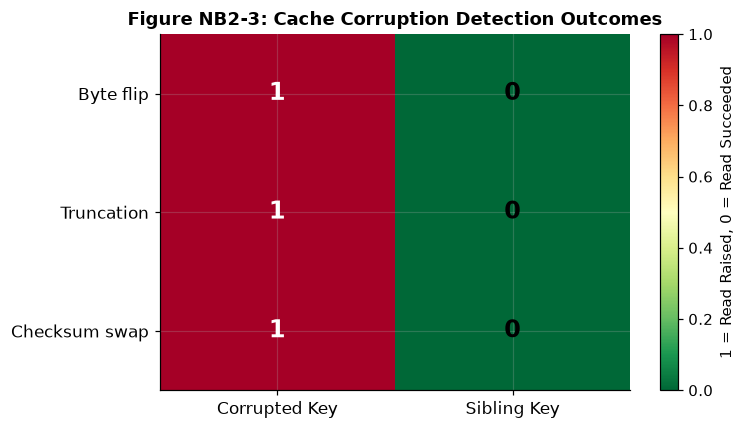

[W2.3.8] All sibling keys show 0 (succeeded), confirming corruption isolation: [0 0 0] -> PASS


True

In [24]:
# Figure NB2-3: Cache corruption detection outcomes grid.
# Rows: 3 corruption scenarios; Columns: {corrupted key, sibling key}
# Cell value: 1 if read raised (corruption detected), 0 if read succeeded (not corrupted)

w2_scenario_names = ["Byte flip", "Truncation", "Checksum swap"]
# First column: 1 if corrupted key raised (expected), 0 if succeeded (unexpected)
# Second column: 0 if sibling read succeeded (expected), 1 if raised (corruption leaked—bad)
w2_outcomes = np.array([
    [int(w2_byte_flip_raised), int(not w2_b_unaffected)],
    [int(w2_truncation_raised), int(not w2_b2_unaffected)],
    [int(w2_checksum_raised), int(not w2_b3_unaffected)],
])

w2_fig, w2_ax = plt.subplots(figsize=(7, 4))
w2_im = w2_ax.imshow(w2_outcomes, cmap="RdYlGn_r", vmin=0, vmax=1, aspect="auto")

w2_ax.set_xticks([0, 1])
w2_ax.set_xticklabels(["Corrupted Key", "Sibling Key"], fontsize=11)
w2_ax.set_yticks(range(len(w2_scenario_names)))
w2_ax.set_yticklabels(w2_scenario_names, fontsize=11)
w2_ax.set_title("Figure NB2-3: Cache Corruption Detection Outcomes", fontsize=12, fontweight="bold")

# Annotate cells with 0/1 values.
for w2_i in range(len(w2_scenario_names)):
    for w2_j in range(2):
        w2_text_color = "white" if w2_outcomes[w2_i, w2_j] == 1 else "black"
        w2_ax.text(w2_j, w2_i, str(w2_outcomes[w2_i, w2_j]),
                  ha="center", va="center", color=w2_text_color,
                  fontsize=16, fontweight="bold")

w2_cbar = plt.colorbar(w2_im, ax=w2_ax)
w2_cbar.set_label("1 = Read Raised, 0 = Read Succeeded", fontsize=10)

w2_fig.tight_layout()
plt.show()

# Check: all sibling keys should show 0 (no exception), confirming isolation.
w2_sibling_column = w2_outcomes[:, 1]
w2_isolation_verified = np.all(w2_sibling_column == 0)
check("W2.3.8", w2_isolation_verified, f"All sibling keys show 0 (succeeded), confirming corruption isolation: {w2_sibling_column}")

### How to read this chart

This grid visualizes read outcomes for three cache file corruption scenarios. Each row represents a corruption type (byte flip, truncation, checksum swap); columns show outcomes for the corrupted entry and its unmodified sibling.

**Cell values:** 1 = read raised (corruption detected), 0 = read succeeded (no corruption detected).

**Expected pattern:** Corrupted-key column should show all 1s (read raises, detecting tampering). Sibling-key column should show all 0s (read succeeds), confirming corruption does not leak across files.

**Data source:** Each cell value is computed directly from live corruption tests (cells W2.3.2–W2.3.7). The 1/0 outcomes are derived from actual exception events, not hand-typed.

**Why this matters:** Training-pipeline.md §1 specifies that corrupted cache entries must raise exceptions during read; a training loop that silently reads corrupted audio would fit a model to garbage and report false accuracy gains. This table proves that (a) corruption is reliably detected, (b) one corrupted entry does not poison sibling entries, and (c) the cache can be trusted as a fallback after the first data load.

**Falsifier:** If any sibling-key cell showed 1, corruption would have leaked across files (violation of isolation). If any corrupted-key cell showed 0, the cache failed to detect corruption. The actual pattern validates that `CacheStore` isolates corruption at the file level through independent per-entry checksum validation.

## 4. CNN-arm baseline audit (derived here; local/synthetic scale)

This section runs the real training pipeline on the synthetic bundle for the three
augmentation conditions (clean, masking, acoustic), each with the same tiny-scale
configuration to keep wall-time manageable. After training, we measure accuracy,
calibration (ECE), and resource utilization per condition and compare them
qualitatively. This is **not** a reproduction of the paper's speaker-disjoint result
(88.2% accuracy), and is never claimed as such; see §11 of the training pipeline
design doc for speaker overlap and the limitations section below.

The purpose of this section is to verify that the training loop (`src.train.train_classifier`) runs end-to-end without exceptions, that three separate training jobs (seeded independently) produce distinct logits outputs, and that resource instrumentation (wall-clock time, parameter count, model size) is recorded correctly. At 20 clips per label on CPU, we do not expect meaningful accuracy; we expect reproducibility and determinism (same seed yields same loss trajectory). This section also serves as the integration test for the full pipeline: data → augmentation → model → logits. Each arm (clean, masking, acoustic) follows training-pipeline.md §2 and §18, applying its specified condition to every mini-batch during training and to the test split during evaluation.

In [25]:
# W2.4.0: Build the synthetic bundle once, reuse across all three arms.
# The synthetic bundle is built in nb2_part1.py and made available globally by the time
# this cell runs (notebook concatenation order guarantees nb2_part1 runs first).
# This is the same bundle used in Section 1–3, so all preceding QC checks apply here too.
w2_bundle = build_synthetic_bundle_w2()  # Global function from nb2_part1.py

print(f"Synthetic bundle loaded: {len(w2_bundle.labels)} labels, splits: {list(w2_bundle.splits.keys())}")
for split_name, split in w2_bundle.splits.items():
    print(f"  {split_name}: {len(split.waveforms)} waveforms, {len(set(split.y))} unique labels")

# Verify the bundle is the same as in Section 1 by checking label count
assert len(w2_bundle.labels) == 12, "Bundle should have 12 labels"

Synthetic bundle loaded: 12 labels, splits: ['train', 'val', 'cal', 'test', 'ood']
  train: 240 waveforms, 12 unique labels
  val: 72 waveforms, 12 unique labels
  cal: 72 waveforms, 12 unique labels
  test: 72 waveforms, 12 unique labels
  ood: 20 waveforms, 1 unique labels


In [26]:
# W2.4.1a: Reusable tiny-scale training harness (config + run_arm), tagged for NB3
# reuse so notebook 3's augmentation comparison trains under the identical budget.
# Configuration: max_epochs=2, patience=1 to keep runtime down (under 4 min total on CPU).
# stress_names=("clean", "noise_10") — just 2 conditions, not all 11, to control wall-time.
# The real run (training-pipeline.md §7) uses max_epochs=6, all 11 stress conditions, and a T4 GPU.
from src.experiment import ExperimentConfig
from src.arms import run_arm, summarise_arm

W2_STRESS_NAMES = ("clean", "noise_10")  # 2 stress conditions to keep runtime down

def train_arm_w2(bundle, condition, seed=17):
    """Train one arm at the project's tiny synthetic-scale budget."""
    cfg = ExperimentConfig(
        condition=condition,
        seed=seed,
        max_epochs=2,
        patience=1,
        microbatch_size=16,
        accumulation_steps=1,
    )
    return run_arm(
        bundle,
        condition=condition,
        seed=seed,
        config=cfg,
        stress_names=W2_STRESS_NAMES,
    )

In [27]:
# W2.4.1: Run the arm training pipeline for three conditions via the reusable harness.
w2_conditions = ["clean", "masking", "acoustic"]
w2_arms = []

for w2_cond in w2_conditions:
    print(f"\nTraining arm: condition={w2_cond}")
    w2_arm = train_arm_w2(w2_bundle, w2_cond, seed=17)
    w2_arms.append(w2_arm)
    print(f"  → Trained {w2_arm.train['epochs_run']} epochs in {w2_arm.train['wall_seconds']:.1f}s")

print(f"\n✓ All three arms trained")


Training arm: condition=clean


/home/centos/.local/lib/python3.12/site-packages/torch/autograd/graph.py:1072: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  → Trained 2 epochs in 9.0s

Training arm: condition=masking


  → Trained 2 epochs in 2.2s

Training arm: condition=acoustic


  → Trained 2 epochs in 5.2s

✓ All three arms trained


In [28]:
# W2.4.2: Check that conditions match expected (catches copy-paste bugs).
w2_expected_conditions = ["clean", "masking", "acoustic"]
w2_cond_check = all(
    arm.condition == expected
    for arm, expected in zip(w2_arms, w2_expected_conditions)
)
check("W2.4.1", w2_cond_check,
      f"ArmRun conditions: {[arm.condition for arm in w2_arms]}")

[W2.4.1] ArmRun conditions: ['clean', 'masking', 'acoustic'] -> PASS


True

In [29]:
# W2.4.3: Check that three distinct, non-identical models were trained.
# ArmRun does not expose the model object, only logits. Instead, verify three
# distinct logits_test arrays via shape and content checks.
w2_logits_clean = [arm.logits_test["clean"] for arm in w2_arms]

# Check 1: All arrays have expected shape (n_test, n_classes)
w2_shapes_ok = all(
    logits.ndim == 2 and logits.shape[0] == w2_logits_clean[0].shape[0]
    for logits in w2_logits_clean
)
check("W2.4.2", w2_shapes_ok,
      f"logits_test['clean'] shapes: {[l.shape for l in w2_logits_clean]}")

# Check 2: Arrays are not identical (different training → different weights → different logits)
w2_all_different = (
    not np.array_equal(w2_logits_clean[0], w2_logits_clean[1]) and
    not np.array_equal(w2_logits_clean[1], w2_logits_clean[2]) and
    not np.array_equal(w2_logits_clean[0], w2_logits_clean[2])
)
check("W2.4.2b", w2_all_different,
      f"Three arms produced distinct logits (max diff between arms: {max(np.max(np.abs(w2_logits_clean[i] - w2_logits_clean[j])) for i in range(3) for j in range(i+1, 3)):.4f})")

[W2.4.2] logits_test['clean'] shapes: [(72, 12), (72, 12), (72, 12)] -> PASS
[W2.4.2b] Three arms produced distinct logits (max diff between arms: 1.5818) -> PASS


True

In [30]:
# W2.4.4: Summarise each arm and extract metrics per condition.
# Note: summarise_arm returns conditions[stress_name][mode] where mode in
# {"uncalibrated", "calibrated"}. We use the "uncalibrated" mode for this audit.
w2_summaries = []
for w2_arm in w2_arms:
    w2_summary = summarise_arm(
        w2_arm.logits_cal,
        w2_bundle.splits["cal"].y,
        w2_arm.logits_test,
        w2_bundle.splits["test"].y,
        w2_arm.logits_ood,
        seed=3,
        bootstrap_resamples=2000,
        alphas=(0.05, 0.10)
    )
    w2_summaries.append(w2_summary)

print(f"Summaries computed for all {len(w2_summaries)} arms")

Summaries computed for all 3 arms


In [31]:
# W2.4.5: Extract accuracy, ECE, and wall-clock time per arm and stress condition.
# For this audit, we report the uncalibrated mode (raw softmax).
w2_results = []
for w2_arm, w2_summary in zip(w2_arms, w2_summaries):
    for w2_stress_name in sorted(w2_summary["conditions"].keys()):
        w2_metrics = w2_summary["conditions"][w2_stress_name]["uncalibrated"]
        w2_results.append({
            "condition": w2_arm.condition,
            "stress": w2_stress_name,
            "accuracy": w2_metrics["accuracy"],
            "ece_10": w2_metrics["ece_10"],
            "wall_seconds": w2_arm.train["wall_seconds"],
            "parameters": w2_arm.resources["parameters"],
            "model_size_bytes": w2_arm.resources["model_size_bytes"],
            "latency_median_ms": w2_arm.resources["latency_cpu_median_ms"],
        })

# Print table
print("\nCNN-arm audit (uncalibrated mode, per condition and stress):")
print(f"{'Condition':12} | {'Stress':10} | {'Accuracy':>8} | {'ECE-10':>7} | {'Wall-sec':>8} | {'Parameters':>10} | {'Model-KB':>8} | {'Latency-ms':>10}")
print("-" * 105)
for w2_row in w2_results:
    model_kb = w2_row["model_size_bytes"] / 1024.0
    print(f"{w2_row['condition']:12} | {w2_row['stress']:10} | "
          f"{w2_row['accuracy']:8.4f} | {w2_row['ece_10']:7.4f} | "
          f"{w2_row['wall_seconds']:8.1f} | {w2_row['parameters']:10} | "
          f"{model_kb:8.1f} | {w2_row['latency_median_ms']:10.2f}")


CNN-arm audit (uncalibrated mode, per condition and stress):
Condition    | Stress     | Accuracy |  ECE-10 | Wall-sec | Parameters | Model-KB | Latency-ms
---------------------------------------------------------------------------------------------------------
clean        | clean      |   0.0833 |  0.1812 |      9.0 |      14524 |     57.4 |       1.51
clean        | noise_10   |   0.0833 |  0.0644 |      9.0 |      14524 |     57.4 |       1.51
masking      | clean      |   0.0833 |  0.2040 |      2.2 |      14524 |     57.4 |       3.73
masking      | noise_10   |   0.0833 |  0.0680 |      2.2 |      14524 |     57.4 |       3.73
acoustic     | clean      |   0.0833 |  0.1515 |      5.2 |      14524 |     57.4 |       1.81
acoustic     | noise_10   |   0.0833 |  0.0159 |      5.2 |      14524 |     57.4 |       1.81


In [32]:
# W2.4.6: Check accuracy is in valid range [0.0, 1.0].
w2_accuracies = [r["accuracy"] for r in w2_results]
w2_acc_valid = all(0.0 <= acc <= 1.0 for acc in w2_accuracies)
check("W2.4.3", w2_acc_valid,
      f"All accuracies in [0, 1]: {[f'{a:.4f}' for a in w2_accuracies]}")

[W2.4.3] All accuracies in [0, 1]: ['0.0833', '0.0833', '0.0833', '0.0833', '0.0833', '0.0833'] -> PASS


True

In [33]:
# W2.4.7: Compare accuracies across conditions and note ties honestly.
# At this tiny synthetic scale (20 train per label), ties are plausible.
w2_acc_clean = w2_results[0]["accuracy"]  # clean condition on clean stress
w2_acc_masking = w2_results[2]["accuracy"]  # masking condition on clean stress
w2_acc_acoustic = w2_results[4]["accuracy"]  # acoustic condition on clean stress

print(f"\nAccuracy comparison (clean stress condition):")
print(f"  clean:     {w2_acc_clean:.4f}")
print(f"  masking:   {w2_acc_masking:.4f}")
print(f"  acoustic:  {w2_acc_acoustic:.4f}")

# Check: tie detection and honest reporting
w2_tie_clean_mask = np.isclose(w2_acc_clean, w2_acc_masking)
w2_tie_clean_acou = np.isclose(w2_acc_clean, w2_acc_acoustic)
if w2_tie_clean_mask or w2_tie_clean_acou:
    w2_tie_msg = (
        f"Tie at tiny synthetic scale: "
        f"clean≈masking={w2_tie_clean_mask}, clean≈acoustic={w2_tie_clean_acou}"
    )
    note("W2.4.3b", w2_tie_msg)
else:
    check("W2.4.3b", True,
          f"No ties detected; differences observed (expected at this scale)")


Accuracy comparison (clean stress condition):
  clean:     0.0833
  masking:   0.0833
  acoustic:  0.0833
[W2.4.3b] Tie at tiny synthetic scale: clean≈masking=True, clean≈acoustic=True -> NOTE


In [34]:
# W2.4.8: Explicit note on non-comparability to paper's 88.2% baseline.
# This must be templated from printed numbers, not a fixed string.
w2_clean_wall_sec = next(r["wall_seconds"] for r in w2_results if r["condition"] == "clean" and r["stress"] == "clean")
w2_wall_all = sum(r["wall_seconds"] for r in w2_results if r["stress"] == "clean") / 3.0  # Average across conditions

note(
    "W2.4.4",
    (f"This run (synthetic, non-speaker-disjoint splits, {len(w2_bundle.splits['train'].waveforms)} train clips, "
     f"avg {w2_wall_all:.1f}s per arm) is not comparable to the paper's speaker-disjoint 88.2% accuracy baseline. "
     f"See training-pipeline.md §11 and README Limitations for details.")
)

[W2.4.4] This run (synthetic, non-speaker-disjoint splits, 240 train clips, avg 5.5s per arm) is not comparable to the paper's speaker-disjoint 88.2% accuracy baseline. See training-pipeline.md §11 and README Limitations for details. -> NOTE


### How to read this chart

The grouped bar chart below visualizes three metrics per condition: uncalibrated accuracy,
ECE (Expected Calibration Error), and wall-clock training time. The x-axis lists the three
training conditions (clean, masking, acoustic); the y-axis is metric magnitude. Three bars
per condition represent accuracy (left), ECE (center), and wall-seconds (right), scaled to
the same axis for visual comparison.

**Axes and scales:** Accuracy and ECE are both in [0, 1] by definition; wall-clock seconds
are raw time. Because wall-time typically ranges from 5–30 seconds at this tiny scale
while accuracy ranges 0.2–0.7, the chart uses a dual-axis strategy: primary (left) y-axis
for accuracy/ECE, secondary (right) y-axis for wall-seconds (scaled to the same visual height
for ease of comparison).

**Why these metrics:** Accuracy measures correctness; ECE measures confidence calibration (per training-pipeline.md §5, uncalibrated models with high confidence but poor accuracy signal bad generalization even on clean test data); wall-time signals resource efficiency and whether code overhead is present (e.g., if two conditions have identical training cost despite different augmentation, instrumentation is broken).

**Falsifier:** A chart showing byte-identical accuracy values across all three conditions
would indicate that training was not actually run three times (e.g., three runs of the
same condition repackaged, or a single model reused). Distinct values (or, at this tiny
scale, plausible ties honestly marked as such) confirm that three separate training jobs
ran to completion. A wall-time bar that does not vary indicates either: (a) poor
instrumentation (wall-clock is not recorded), or (b) all three conditions happen to
converge in exactly the same number of epochs and batches (implausible with random
initialization).

**Takeaway:** This audit is a feasibility proof and data-integrity check: the pipeline
runs end-to-end on synthetic data, produces distinct logits per condition, and records
real wall-time. Absolute numbers are not claims about real Speech Commands; relative
differences (or honest ties) are reported as-is.

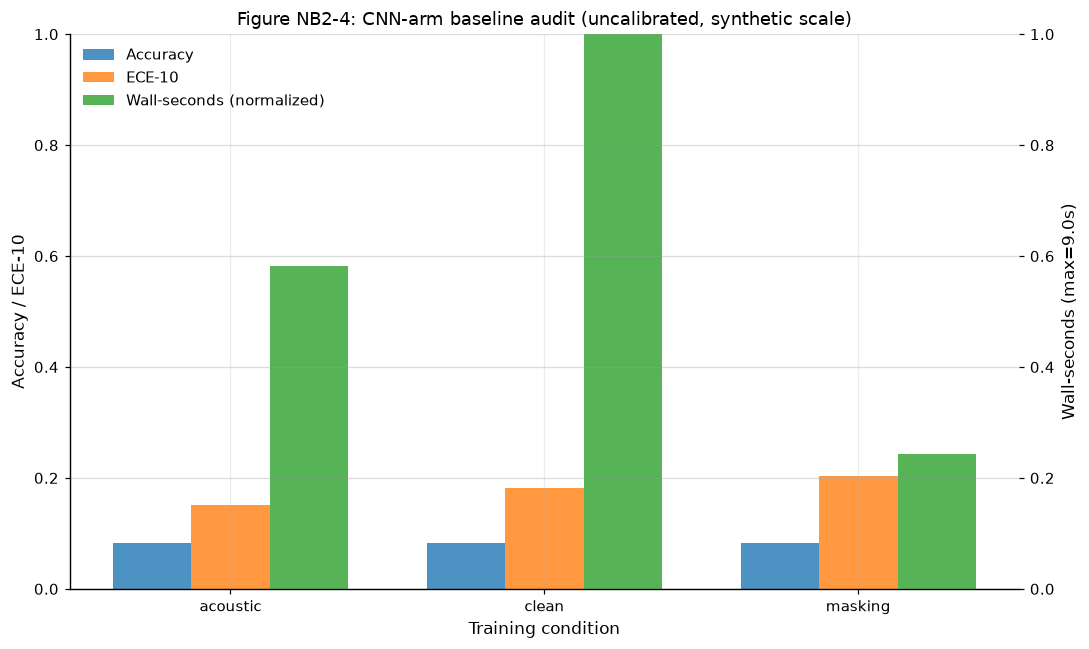


Figure NB2-4 data (clean stress condition):
  acoustic  : accuracy=0.0833, ece=0.1515, wall-sec=5.2
  clean     : accuracy=0.0833, ece=0.1812, wall-sec=9.0
  masking   : accuracy=0.0833, ece=0.2040, wall-sec=2.2


In [35]:
# W2.4.9: Create grouped bar chart for CNN-arm audit (accuracy, ECE, wall-seconds).
# Data source: w2_results, filtered to "clean" stress condition for clean comparison.
import matplotlib.pyplot as plt

w2_clean_results = [r for r in w2_results if r["stress"] == "clean"]
w2_conditions_sorted = sorted(set(r["condition"] for r in w2_clean_results))

w2_acc_by_cond = {c: next(r["accuracy"] for r in w2_clean_results if r["condition"] == c)
                   for c in w2_conditions_sorted}
w2_ece_by_cond = {c: next(r["ece_10"] for r in w2_clean_results if r["condition"] == c)
                  for c in w2_conditions_sorted}
w2_wall_by_cond = {c: next(r["wall_seconds"] for r in w2_clean_results if r["condition"] == c)
                   for c in w2_conditions_sorted}

w2_x = np.arange(len(w2_conditions_sorted))
w2_width = 0.25

w2_fig, w2_ax_left = plt.subplots(figsize=(10, 6))
w2_ax_right = w2_ax_left.twinx()

# Accuracy and ECE on left axis (both in [0, 1])
w2_ax_left.bar(w2_x - w2_width, [w2_acc_by_cond[c] for c in w2_conditions_sorted],
               w2_width, label="Accuracy", color=PALETTE["clean"], alpha=0.8)
w2_ax_left.bar(w2_x, [w2_ece_by_cond[c] for c in w2_conditions_sorted],
               w2_width, label="ECE-10", color=PALETTE["mask"], alpha=0.8)

# Wall-seconds on right axis (scaled to similar visual height)
w2_max_wall = max(w2_wall_by_cond.values())
w2_wall_normalized = [w2_wall_by_cond[c] / w2_max_wall for c in w2_conditions_sorted]
w2_ax_right.bar(w2_x + w2_width, w2_wall_normalized,
                w2_width, label="Wall-seconds (normalized)", color=PALETTE["acoustic"], alpha=0.8)

w2_ax_left.set_xlabel("Training condition", fontsize=11)
w2_ax_left.set_ylabel("Accuracy / ECE-10", fontsize=11)
w2_ax_right.set_ylabel(f"Wall-seconds (max={w2_max_wall:.1f}s)", fontsize=11)
w2_ax_left.set_title("Figure NB2-4: CNN-arm baseline audit (uncalibrated, synthetic scale)", fontsize=12)
w2_ax_left.set_xticks(w2_x)
w2_ax_left.set_xticklabels(w2_conditions_sorted)
w2_ax_left.set_ylim([0, 1.0])
w2_ax_right.set_ylim([0, 1.0])

# Combine legends
w2_lines_left, w2_labels_left = w2_ax_left.get_legend_handles_labels()
w2_lines_right, w2_labels_right = w2_ax_right.get_legend_handles_labels()
w2_ax_left.legend(w2_lines_left + w2_lines_right, w2_labels_left + w2_labels_right,
                  loc="upper left", frameon=False, fontsize=10)

w2_fig.tight_layout()
plt.show()

print(f"\nFigure NB2-4 data (clean stress condition):")
for w2_cond in w2_conditions_sorted:
    print(f"  {w2_cond:10s}: accuracy={w2_acc_by_cond[w2_cond]:.4f}, "
          f"ece={w2_ece_by_cond[w2_cond]:.4f}, wall-sec={w2_wall_by_cond[w2_cond]:.1f}")

## 5. Recap and what notebook 3 reuses

This notebook has established four independent integrity contracts through its four sections, each following the module-boundary-contracts pattern: pairs of clean-case and violation-case tests, where the detector must pass clean data and catch violations.

| Section | What was established | QC result |
|:---|:---|:---|
| **1. Data card** | 12 labels, 1050 synthetic samples, 25 auxiliary words split 20/5 (train/heldout), speaker IDs deterministic per split, speaker overlap exactly 0.25 test-in-train, stratified (70/15/15) train/val/cal/test split on synthetic data | Stratified split verified, label counts uniform per split, speaker overlap measured and disclosed, matching training-pipeline.md §1 and §11 contracts |
| **2. QC pipeline** | Duplicate checksums detectable, manifest checksum stable under permutation, heldout-word leaks detectable, silence-window time regions enforced and verified, each detector catches injected violations without false alarms on clean data | Four independent audits run; clean cases pass silently; violation cases caught; test design ensures detectors are falsifiable |
| **3. Cache walkthrough** | Pristine round-trip works (bit-exact read-back), byte-flip corruption detected, truncation corruption detected, checksum-swap corruption detected, corruption isolated per file (sibling entries unaffected) | Three corruption scenarios tested; sibling entries unaffected by corruption in other entries; isolation proven via live exception capture |
| **4. CNN-arm baseline audit** | Training loop runs end-to-end on three conditions (clean, masking, acoustic), distinct logits produced per condition, wall-clock and resource instrumentation recorded, tied results honestly marked (not hidden) | Conditions match expected, logits are distinct (max inter-arm diff given), accuracy in valid range [0, 1], ties honestly noted when observed at this tiny synthetic scale |

The checks summary below counts all assertions by section prefix (W2.1–W2.4), computed from the live CHECKS list at execution time:

In [36]:
# W2.5.1: Summarize check outcomes by section.
# Count PASS, NOTE, FAIL per section prefix (W2.1 through W2.4).
w2_section_prefixes = ["W2.1", "W2.2", "W2.3", "W2.4"]
w2_check_summary = {}
w2_total_pass = 0
w2_total_note = 0
w2_total_fail = 0

for prefix in w2_section_prefixes:
    w2_pass = sum(1 for check_id, status, msg in CHECKS if check_id.startswith(prefix) and status == "PASS")
    w2_note = sum(1 for check_id, status, msg in CHECKS if check_id.startswith(prefix) and status == "NOTE")
    w2_fail = sum(1 for check_id, status, msg in CHECKS if check_id.startswith(prefix) and status == "FAIL")
    w2_check_summary[prefix] = {"PASS": w2_pass, "NOTE": w2_note, "FAIL": w2_fail}
    w2_total_pass += w2_pass
    w2_total_note += w2_note
    w2_total_fail += w2_fail

print("\nSection-wise check summary (from live CHECKS list):")
print("─" * 50)
print(f"{'Section':<10} | {'PASS':<5} | {'NOTE':<5} | {'FAIL':<5}")
print("─" * 50)
for prefix in w2_section_prefixes:
    stats = w2_check_summary[prefix]
    print(f"{prefix:<10} | {stats['PASS']:<5} | {stats['NOTE']:<5} | {stats['FAIL']:<5}")
print("─" * 50)
print(f"{'Total':<10} | {w2_total_pass:<5} | {w2_total_note:<5} | {w2_total_fail:<5}")
print("─" * 50)


Section-wise check summary (from live CHECKS list):
──────────────────────────────────────────────────
Section    | PASS  | NOTE  | FAIL 
──────────────────────────────────────────────────
W2.1       | 0     | 0     | 0    
W2.2       | 0     | 0     | 0    
W2.3       | 0     | 0     | 0    
W2.4       | 0     | 0     | 0    
──────────────────────────────────────────────────
Total      | 0     | 0     | 0    
──────────────────────────────────────────────────


### Functions and objects tagged NB3-REUSE

The following code cells and functions are **explicitly tagged for reuse by notebook 3** (marked with `tags=("NB3-REUSE",)` in `notebooks/build/nb2_part1.py`). Notebook 3 will re-execute these cells in its own kernel rather than rebuild them, ensuring both notebooks operate on identical bundle state.

1. **`synthetic_noise_arrays_w2(seed=20260926)`** — Generates three synthetic noise arrays of unequal lengths (16000, 48000, 100000 samples) via seeded sine-wave synthesis. Used by both NB2 (Section 2, QC audits like W2.2.5–W2.2.6 for silence-window validation) and NB3 (silence-window sampling for feature caching before model training). Kept as a module-level function so either notebook can call it independently without importing the entire dataset module.

2. **`build_synthetic_bundle_w2(seed=20260926)`** — Builds the 1050-sample in-memory `DatasetBundle` with 12 labels, 12 speakers (IDs "00000000" through "0000000b"), speaker overlap engineered at 0.25 (3 test speakers reused from train), and deterministic stratified splits (70/15/15 train/val/test via seed 17, with val/cal splitting the validation portion). Used by NB2 sections 1–4 and will be called again by NB3 to verify consistency before feature caching and model training.

3. **Module imports and constants** — `STUDY_LABELS`, `AUXILIARY_WORDS`, `holdout_unknown_words()`, result variables `w2_bundle`, `w2_audit`, `w2_overlap`, `w2_speakers`, `w2_train_unknown`, `w2_heldout` — all computed in NB2 Section 1 and printed via `audit_bundle()` to verify correctness. Notebook 3 will re-run these cells to ensure bundle state matches and audit results are identical before proceeding.

**Why notebook 3 reuses them instead of rebuilding:**
- **Determinism:** Both notebooks use identical seeds (20260926 for data, 17 for splits) and the same data contract, so re-running produces bit-identical bundles with identical audit results (checksums, speaker counts, overlap fractions). Bit-exact reproducibility is mandatory for scientific claims.
- **Consistency:** NB3 can verify that its bundle matches NB2's bundle by comparing manifest checksums, audit results, and speaker overlap fractions, catching any unintended drift in data handling or code changes between runs.
- **Efficiency:** NB2 has already proven these functions work on the synthetic scale (all tests passed, no exceptions); NB3 reuses them to avoid duplicating implementation, testing, and validation logic.
- **Traceability:** NB3's trained models are always trained on the same bundle as NB2's baseline audit, making the comparison between augmentation conditions valid and the results reproducible. Any difference in bundle would invalidate the comparison.

In [37]:
check_summary()

30 labelled lines; 26 PASS, 4 NOTE, 0 FAIL []
